# EMA 7/21 Cross — Signal Exploration

Interactive notebook for slicing the signal by date range, comparing years, and sweeping hold periods.

**Workflow:**
1. Run **cell 2** once to load data and build features (cached after first run)
2. Run **cell 4** once to define helpers
3. Then run any of the exploration cells freely — each is independent

In [1]:
from datetime import datetime, timezone

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from cryocore.instruments import Symbol
from cryoquant.data.loader import load
from cryoquant.features.builders import DatasetRef, DailyEmaCrossFeatures

sym    = Symbol("binance.spot", "BTCUSDT")
df_raw = load(
    sym, "1d",
    datetime(2020, 1, 1, tzinfo=timezone.utc),
    datetime.now(timezone.utc),
)

ref      = DatasetRef(sym, "1d")
X        = DailyEmaCrossFeatures().build({ref: df_raw})
new_cols = [c for c in X.columns if c not in df_raw.columns]
bars     = df_raw.join(X[new_cols])

print(f"✓ {len(bars)} daily bars  ({bars.index[0].date()} → {bars.index[-1].date()})")
print(f"  Up crosses  : {int(X['cross_up'].fillna(False).sum())}")
print(f"  Down crosses: {int(X['cross_down'].fillna(False).sum())}")

✓ 2330 daily bars  (2020-01-01 → 2026-05-18)
  Up crosses  : 54
  Down crosses: 54


## Helper functions

`run(start, end, leg, hold, fee_bps)` — simulate over any date window and return a `SpotResult`.  
`plot_equity(result, title)` — equity curve + drawdown chart with metrics printed below.

In [2]:
from cryoquant.backtest.spot_pnl import simulate
from cryoquant.signals.ema_cross import make_ema_cross_long, make_ema_cross_short


def run(start=None, end=None, leg="long", hold=5, fee_bps=5.0):
    """Simulate the EMA 7/21 cross over a date window.

    Parameters
    ----------
    start, end : str | None  — e.g. "2021", "2022-06", "2023-01-01"
    leg        : "long" | "short"
    hold       : bars to hold after entry (daily bars ≈ calendar days)
    fee_bps    : round-trip fee in basis points
    """
    window = bars[start:end]
    signal = make_ema_cross_long() if leg == "long" else make_ema_cross_short()
    return simulate(signal, window, hold_h=hold, fee_bps=fee_bps)


def plot_equity(result, title=""):
    """Equity curve + drawdown chart."""
    equity   = result.equity
    roll_max = equity.cummax()
    drawdown = equity / roll_max - 1

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 6),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    ax1.plot(equity.index, equity.values, color="#2196F3", lw=1.5)
    ax1.axhline(1.0, color="#888", lw=0.8, ls="--")
    ax1.set_ylabel("Equity (normalised)")
    ax1.set_title(title or "EMA 7/21 Cross")
    ax1.grid(True, alpha=0.25)

    ax2.fill_between(drawdown.index, drawdown.values, 0, color="#F44336", alpha=0.35)
    ax2.set_ylabel("Drawdown")
    ax2.grid(True, alpha=0.25)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.show()

    m = result.metrics
    print(
        f"  n_trades={m['n_trades']}  return={m['total_return']:.1%}  "
        f"win_rate={m['win_rate']:.1%}  sharpe={m['sharpe']:.2f}  "
        f"max_dd={m['max_drawdown']:.1%}  expectancy={m['expectancy']:.2%}/trade"
    )


print("Helpers ready.")

Helpers ready.


## Full history overview

Jan 2020 → today. Long and short legs side by side.

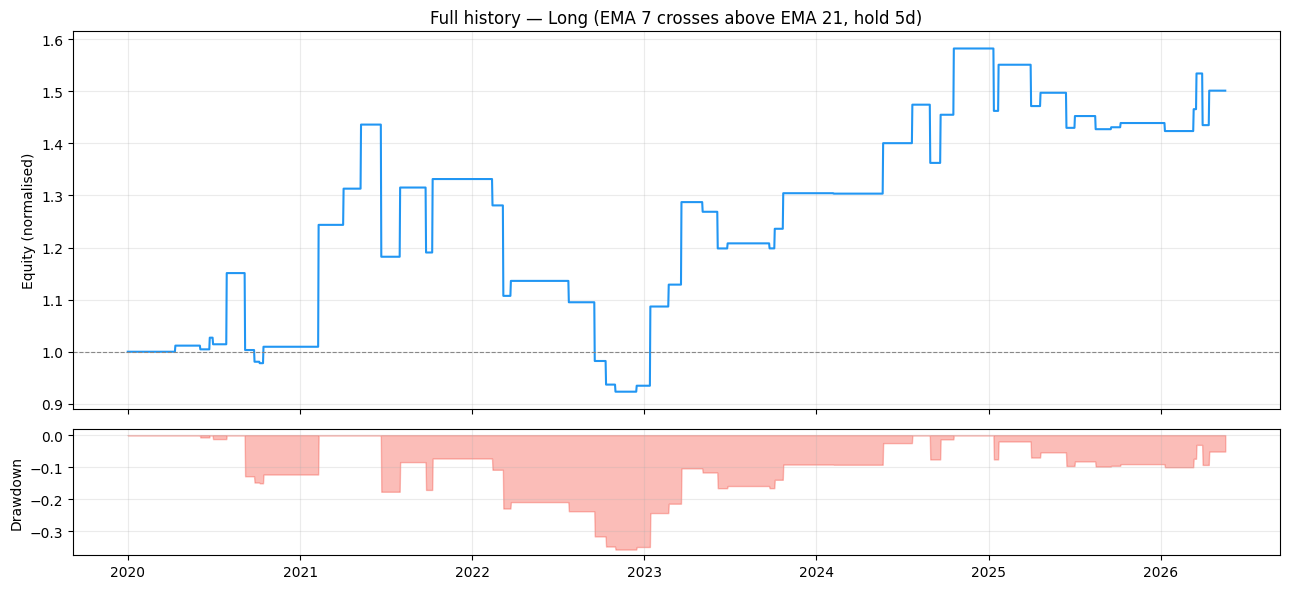

  n_trades=53  return=50.1%  win_rate=54.7%  sharpe=2.19  max_dd=-35.7%  expectancy=1.05%/trade


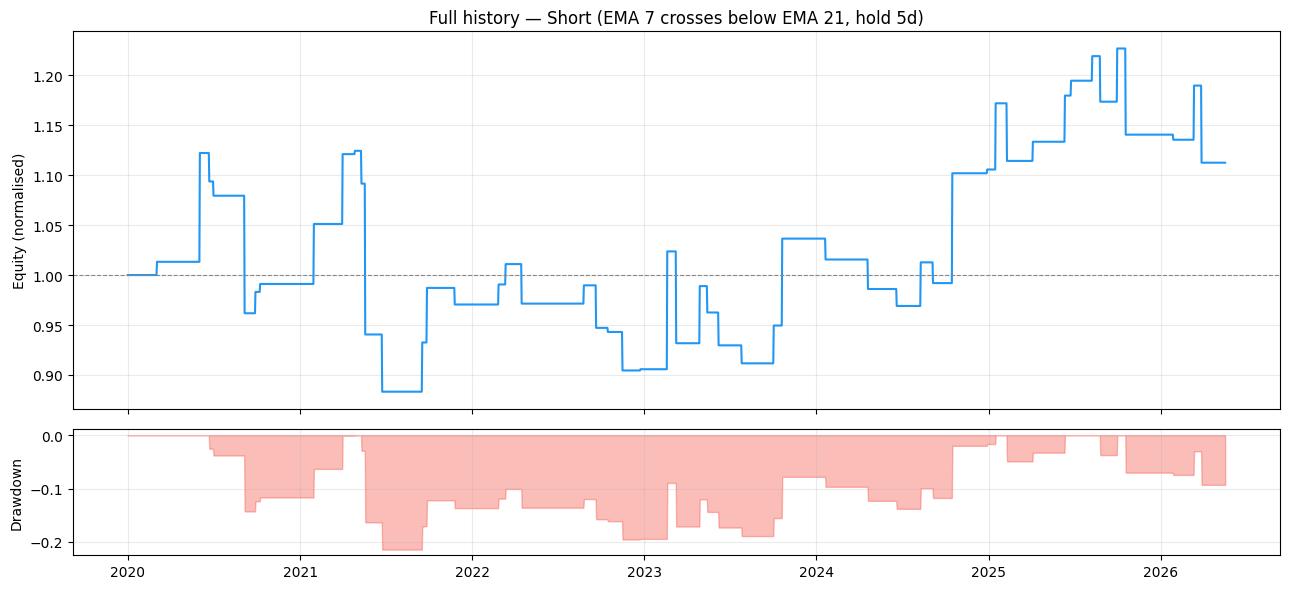

  n_trades=51  return=11.2%  win_rate=52.9%  sharpe=1.03  max_dd=-21.4%  expectancy=0.36%/trade


In [3]:
plot_equity(run(leg="long"),  title="Full history — Long (EMA 7 crosses above EMA 21, hold 5d)")
plot_equity(run(leg="short"), title="Full history — Short (EMA 7 crosses below EMA 21, hold 5d)")

## Year-by-year breakdown

How did each calendar year perform? Cells are coloured by Sharpe — green = good, red = bad.

In [4]:
current_year = datetime.now().year
rows = []
for yr in range(2020, current_year + 1):
    for leg in ("long", "short"):
        r = run(str(yr), str(yr), leg=leg)
        rows.append({"year": yr, "leg": leg, **r.metrics})

df_years = (
    pd.DataFrame(rows)
    .set_index(["year", "leg"])
    [["n_trades", "total_return", "win_rate", "sharpe", "max_drawdown", "expectancy"]]
)

df_years.style.format({
    "total_return": "{:.1%}",
    "win_rate":     "{:.1%}",
    "sharpe":       "{:.2f}",
    "max_drawdown": "{:.1%}",
    "expectancy":   "{:.2%}",
}).background_gradient(subset=["sharpe"], cmap="RdYlGn", vmin=-1, vmax=3)

## Hold period sensitivity

Does holding longer help or hurt? Sweeps 2 → 20 days on the long leg over the full history.

In [5]:
rows = []
for h in [2, 3, 5, 7, 10, 15, 20]:
    r = run(leg="long", hold=h)
    rows.append({"hold_days": h, **r.metrics})

df_hold = (
    pd.DataFrame(rows)
    .set_index("hold_days")
    [["n_trades", "total_return", "win_rate", "sharpe", "max_drawdown", "expectancy"]]
)

df_hold.style.format({
    "total_return": "{:.1%}",
    "win_rate":     "{:.1%}",
    "sharpe":       "{:.2f}",
    "max_drawdown": "{:.1%}",
    "expectancy":   "{:.2%}",
}).background_gradient(subset=["sharpe"], cmap="RdYlGn", vmin=-1, vmax=3)

,n_trades,total_return,win_rate,sharpe,max_drawdown,expectancy
hold_days,,,,,,
2,53,4.0%,58.5%,0.62,-29.9%,0.18%
3,53,-1.7%,52.8%,0.36,-27.8%,0.13%
5,53,50.1%,54.7%,2.19,-35.7%,1.05%
7,51,91.8%,54.9%,3.19,-32.1%,1.57%
10,49,82.5%,55.1%,2.78,-29.9%,1.66%
15,46,51.6%,50.0%,2.08,-55.1%,1.75%
20,40,198.7%,57.5%,4.31,-35.1%,3.59%


## Custom window

Edit `START`, `END`, `LEG`, and `HOLD` — then re-run this cell.

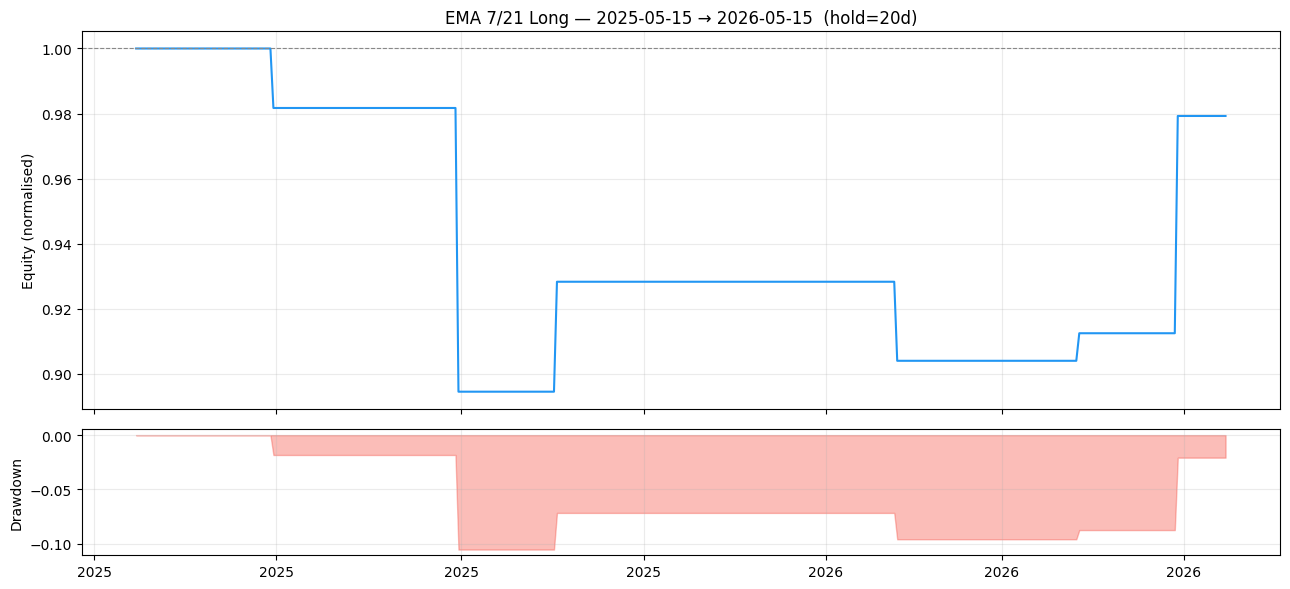

  n_trades=6  return=-2.1%  win_rate=50.0%  sharpe=-0.61  max_dd=-10.5%  expectancy=-0.22%/trade


,entry_ts,exit_ts,entry_price,exit_price,pnl_pct,fee_pct
0,2025-06-10 00:00:00+00:00,2025-06-30 00:00:00+00:00,110263.02,108356.93,-1.83%,0.1000%
1,2025-08-11 00:00:00+00:00,2025-08-31 00:00:00+00:00,119294.27,108816.33,-8.88%,0.1000%
2,2025-09-13 00:00:00+00:00,2025-10-03 00:00:00+00:00,116029.41,120529.35,+3.78%,0.1000%
3,2026-01-05 00:00:00+00:00,2026-01-25 00:00:00+00:00,91529.74,89225.34,-2.62%,0.1000%
4,2026-03-07 00:00:00+00:00,2026-03-27 00:00:00+00:00,68114.02,68820.31,+0.94%,0.1000%
5,2026-04-09 00:00:00+00:00,2026-04-29 00:00:00+00:00,71069.93,76342.78,+7.32%,0.1000%


In [7]:
# ── Edit these and re-run ────────────────────────────────────────────────────
START = "2025-05-15"
END   = "2026-05-15"
LEG   = "long"    # "long" or "short"
HOLD  = 20         # bars to hold after entry
# ─────────────────────────────────────────────────────────────────────────────

r = run(START, END, leg=LEG, hold=HOLD)
plot_equity(r, title=f"EMA 7/21 {LEG.title()} — {START} → {END}  (hold={HOLD}d)")

r.trades.style.format({
    "entry_price": "{:.2f}",
    "exit_price":  "{:.2f}",
    "pnl_pct":     "{:+.2%}",
    "fee_pct":     "{:.4%}",
}).background_gradient(subset=["pnl_pct"], cmap="RdYlGn", vmin=-0.1, vmax=0.1)